In [49]:
import laspy
import numpy as np
import pandas as pd
import lasio
import matplotlib.pyplot as plt
import plotly.express as px


In [50]:
from pathlib import Path

# Robust path handling: try workspace-relative and absolute paths
possible_paths = [
    Path("Excerise_1") / "Datasets" / "Formation Tops.xlsx",
    Path("./Excerise_1") / "Datasets" / "Formation Tops.xlsx",
    Path("/workspaces/well_data_preprocessing/Excerise_1/Datasets/Formation Tops.xlsx")
]

xlsx_path = None
for p in possible_paths:
    if p.exists():
        xlsx_path = p
        break

if xlsx_path is None:
    raise FileNotFoundError(
        "Could not find 'Formation Tops.xlsx'. Expected one of: " +
        ", ".join(str(p) for p in possible_paths)
    )

# Read Excel
df = pd.read_excel(xlsx_path)
# Ensure numeric depth
df["Top depth [mMD_RKB]"] = df["Top depth [mMD_RKB]"].astype('float64')


In [51]:
df

,Well #,Formation,Top depth [mMD_RKB]
0,XX-X,FM-1,406.0
1,XX-X,FM-2,478.0
2,XX-X,FM-3,639.0
3,XX-X,FM-4,674.0
4,XX-X,FM-5,702.0
5,XX-X,FM-6,729.0
6,XX-X,FM-7,790.0
7,XX-X,FM-8,807.0
8,XX-X,FM-9,1168.0
9,XX-X,FM-10,1517.0


In [52]:
from pathlib import Path

possible_paths = [
    Path("Excerise_1") / "Datasets" / "Well Log.LAS",
    Path("./Excerise_1") / "Datasets" / "Well Log.LAS",
    Path("/workspaces/well_data_preprocessing/Excerise_1/Datasets/Well Log.LAS")
]

las_path = None
for p in possible_paths:
    if p.exists():
        las_path = p
        break

if las_path is None:
    raise FileNotFoundError(
        "Could not find 'Well Log.LAS'. Expected one of: " +
        ", ".join(str(p) for p in possible_paths)
    )

las = lasio.read(las_path)


In [53]:
df_logs = las.df()
df_logs = df_logs.replace(-999.25, np.nan)
df_logs


,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,RDEP,RMED,RMIC,ROP,TH,U
DEPT,,,,,,,,,,,,,,,,
405.9936,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.1460,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.2984,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.4508,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.6032,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2209.6476,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.6901,NaN,NaN
2209.8000,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.7076,NaN,NaN
2209.9524,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.1661,NaN,NaN


In [54]:
# Nulls først (se punkt 3)
df_logs["Vp"] = (1e6 / df_logs["AC"]) * 0.3048      # m/s
df_logs["Vs"] = (1e6 / df_logs["ACS"]) * 0.3048     # m/s

df_logs["AI"] = df_logs["Vp"] * (df_logs["DEN"])  # (m/s)*(kg/m3)
df_logs["Vp/Vs"] = df_logs["Vp"] / df_logs["Vs"]


In [55]:
df_logs.columns

Index(['AC', 'ACS', 'BS', 'CALI', 'DEN', 'DENC', 'GR', 'K', 'NEU', 'PEF',
       'RDEP', 'RMED', 'RMIC', 'ROP', 'TH', 'U', 'Vp', 'Vs', 'AI', 'Vp/Vs'],
      dtype='str')

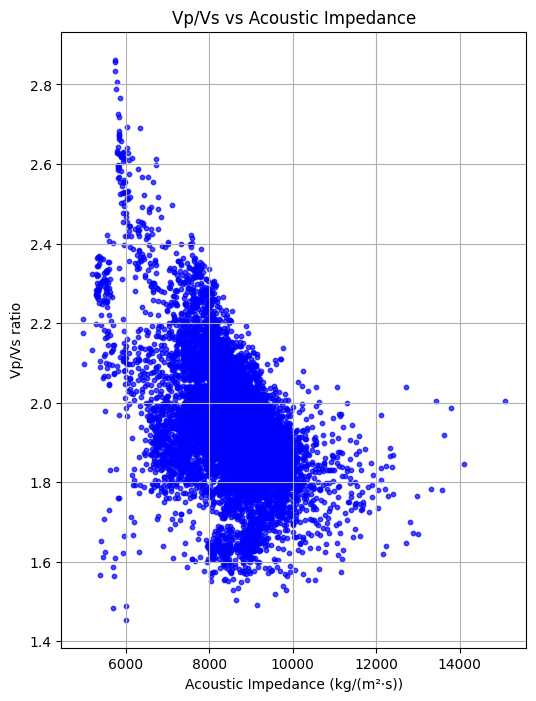

In [56]:
plt.figure(figsize=(6,8))
plt.scatter(df_logs["AI"], df_logs["Vp/Vs"], c='blue', s=10, alpha=0.7)
plt.xlabel("Acoustic Impedance (kg/(m²·s))")
plt.ylabel("Vp/Vs ratio")
plt.title("Vp/Vs vs Acoustic Impedance")
plt.grid(True)
plt.show()


In [57]:
df_logs_with_form = pd.merge_asof(
    df_logs.sort_values("DEPT"),
    df,
    left_on="DEPT",
    right_on="Top depth [mMD_RKB]",
    direction="backward"
)


In [58]:
df_logs_with_form

,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,...,ROP,TH,U,Vp,Vs,AI,Vp/Vs,Well #,Formation,Top depth [mMD_RKB]
0,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
2,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
3,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
4,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11835,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.6901,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11836,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.7076,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11837,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.1661,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11838,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.8002,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0


In [59]:
df_clean = df_logs_with_form.rename(columns={"Top depth [mMD_RKB]": "Depth"})


In [60]:
df_clean

,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,...,ROP,TH,U,Vp,Vs,AI,Vp/Vs,Well #,Formation,Depth
0,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
2,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
3,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
4,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11835,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.6901,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11836,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.7076,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11837,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.1661,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11838,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.8002,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0


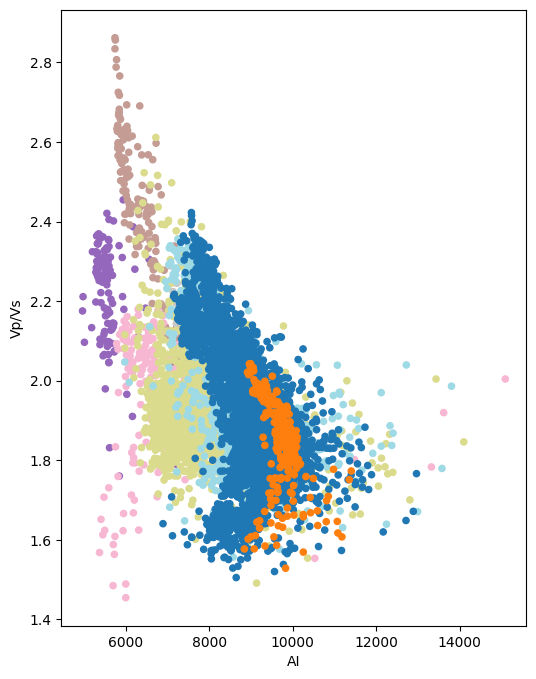

In [61]:
df_clean['Formation_code'] = pd.Categorical(df_clean['Formation']).codes

# Simple scatter
plt.figure(figsize=(6,8))
plt.scatter(df_clean['AI'], df_clean['Vp/Vs'], c=df_clean['Formation_code'], cmap='tab20', s=20)
plt.gca() # depth usually goes downward
plt.xlabel('AI')      # replace with your X-axis
plt.ylabel('Vp/Vs')
plt.show()


In [62]:
# Check if all data points for each formation have the same depth
depth_counts = df_clean.groupby('Formation')['Depth'].nunique()

# Also show min and max depth per formation
depth_ranges = df_clean.groupby('Formation')['Depth'].agg(['min', 'max', 'count'])

# Reset index to make DEPT a column
df_clean = df_clean.reset_index()

# Rename the index column to DEPT
df_clean = df_clean.rename(columns={'index': 'DEPT'})

# Add Formation_code to df_clean
df_clean['Formation_code'] = df_clean['Formation'].astype(str)

fig = px.scatter_3d(
    df_clean,
    x='AI',
    z='DEPT',  # use actual log depth for varying depths within formations
    y='Vp/Vs',
    color='Formation_code',   # color by formation
    size_max=1
)
fig.update_traces(marker=dict(line=dict(width=1, color='black')))
fig.update_layout(scene=dict(zaxis=dict(autorange='reversed')))  # Depth goes downward
fig.show()

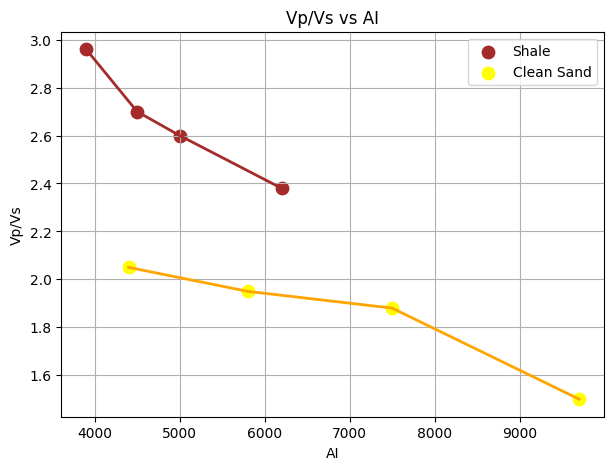

In [63]:
#Ca, egenlagd template basert på ødegaard sine empiriske data.
shale = [(3900, 2.96), (4500, 2.7), (5000, 2.6), (6200, 2.38)]

clean_sand = [(4400, 2.05), (5800, 1.95), (7500, 1.88), (9700, 1.5)]

shale_x, shale_y = zip(*shale)
sand_x, sand_y = zip(*clean_sand)

plt.figure(figsize=(7,5))
plt.scatter(shale_x, shale_y, color='brown', label='Shale', s=80)
plt.scatter(sand_x, sand_y, color='yellow', label='Clean Sand', s=80)
plt.plot(shale_x, shale_y, color='brown', linestyle='-', linewidth=2)
plt.plot(sand_x, sand_y, color='orange', linestyle='-', linewidth=2)
plt.xlabel('AI')
plt.ylabel('Vp/Vs')
plt.title('Vp/Vs vs AI')
plt.legend()
plt.grid(True)
plt.show()


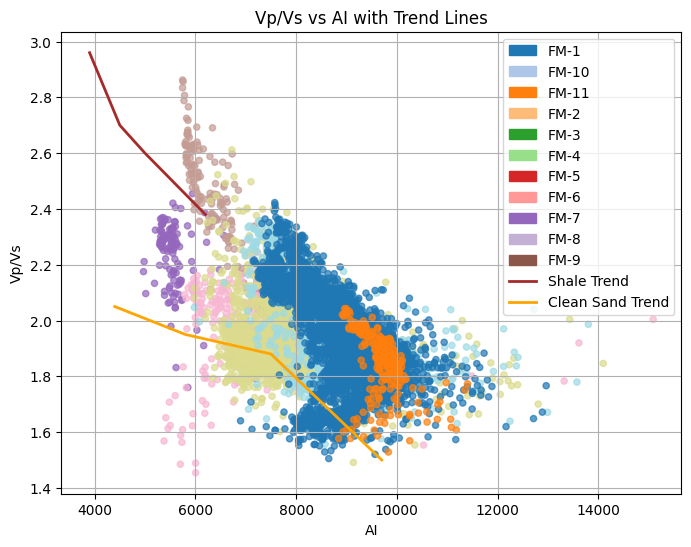

In [68]:
shale = [(3900, 2.96), (4500, 2.7), (5000, 2.6), (6200, 2.38)]
clean_sand = [(4400, 2.05), (5800, 1.95), (7500, 1.88), (9700, 1.5)]

shale_x, shale_y = zip(*shale)
sand_x, sand_y = zip(*clean_sand)

# Scatter from your dataframe
# Assuming df_clean has columns: 'AI', 'Vp/Vs', 'Formation'
df_clean['Formation_code'] = pd.Categorical(df_clean['Formation']).codes

plt.figure(figsize=(8,6))

# Scatter of actual data (colored by formation)
plt.scatter(df_clean['AI'], df_clean['Vp/Vs'], 
            c=df_clean['Formation_code'], cmap='tab20', s=20, alpha=0.7)

# Plot trend lines (shale and sand)
plt.plot(shale_x, shale_y, color='brown', linestyle='-', linewidth=2, label='Shale Trend')
plt.plot(sand_x, sand_y, color='orange', linestyle='-', linewidth=2, label='Clean Sand Trend')

plt.xlabel('AI')
plt.ylabel('Vp/Vs')
plt.title('Vp/Vs vs AI with Trend Lines')

# Create legend for formations and trends
import matplotlib.patches as mpatches
formations = pd.Categorical(df_clean['Formation']).categories
patches = [mpatches.Patch(color=plt.cm.tab20(i), label=str(formation)) for i, formation in enumerate(formations)]
# Add trend lines
patches.extend([plt.Line2D([0], [0], color='brown', lw=2, label='Shale Trend'),
                plt.Line2D([0], [0], color='orange', lw=2, label='Clean Sand Trend')])
plt.legend(handles=patches)

plt.grid(True)
plt.show()

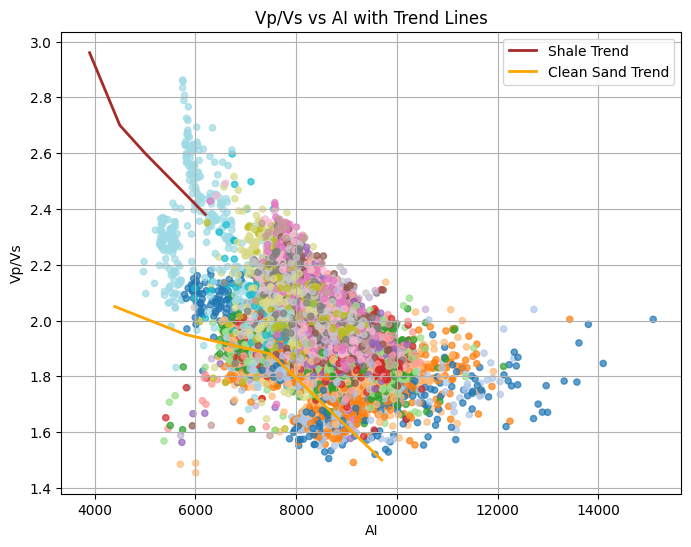

In [69]:
shale = [(3900, 2.96), (4500, 2.7), (5000, 2.6), (6200, 2.38)]
clean_sand = [(4400, 2.05), (5800, 1.95), (7500, 1.88), (9700, 1.5)]

shale_x, shale_y = zip(*shale)
sand_x, sand_y = zip(*clean_sand)

# Scatter from your dataframe
# Assuming df_clean has columns: 'AI', 'Vp/Vs', 'Formation'
df_clean['GR_color'] = pd.Categorical(df_clean['GR']).codes

plt.figure(figsize=(8,6))

# Scatter of actual data (colored by formation)
plt.scatter(df_clean['AI'], df_clean['Vp/Vs'], 
            c=df_clean['GR_color'], cmap='tab20', s=20, alpha=0.7)

# Plot trend lines (shale and sand)
plt.plot(shale_x, shale_y, color='brown', linestyle='-', linewidth=2, label='Shale Trend')
plt.plot(sand_x, sand_y, color='orange', linestyle='-', linewidth=2, label='Clean Sand Trend')

plt.xlabel('AI')
plt.ylabel('Vp/Vs')
plt.title('Vp/Vs vs AI with Trend Lines')
plt.legend()
plt.grid(True)
plt.show()


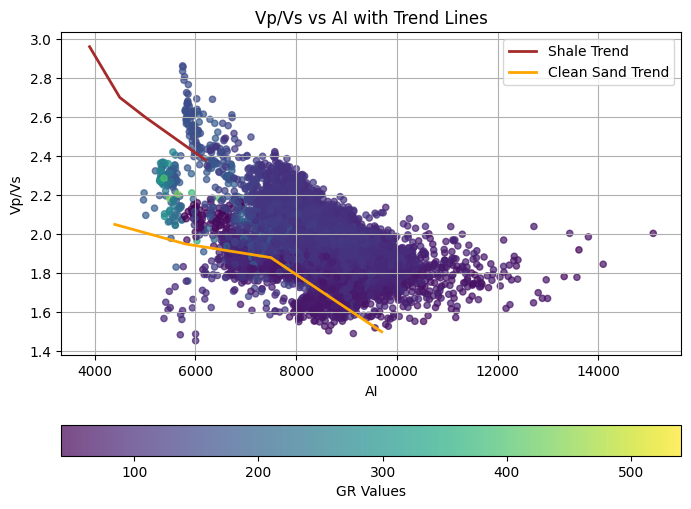

In [70]:
plt.figure(figsize=(8,6))

# Scatter of actual data (colored by GR values now, using a continuous colormap)
plt.scatter(df_clean['AI'], df_clean['Vp/Vs'], 
            c=df_clean['GR'], cmap='viridis', s=20, alpha=0.7)  # Changed 'GR_color' to 'GR' and 'tab20' to 'viridis' for continuous coloring

# Plot trend lines (shale and sand)
plt.plot(shale_x, shale_y, color='brown', linestyle='-', linewidth=2, label='Shale Trend')
plt.plot(sand_x, sand_y, color='orange', linestyle='-', linewidth=2, label='Clean Sand Trend')

plt.xlabel('AI')
plt.ylabel('Vp/Vs')
plt.title('Vp/Vs vs AI with Trend Lines')
plt.legend()
plt.grid(True)

# Add color bar at the bottom
plt.colorbar(orientation='horizontal', label='GR Values')

plt.show()